# Training Logic & Extraction Experiments
**DocFusion Challenge — Rihal CodeStacker 2026**

This notebook picks up where the EDA left off. Now that I understand the data, this covers the actual building process — how the extraction pipeline evolved through trial and error, how the anomaly detection model was trained, and what worked vs what didn't.

In [1]:
import os
import re
import json
import csv
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pytesseract

import platform
if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# dataset paths
sroie_img = os.path.join('..', 'Datasets', 'SROIE2019', 'train', 'img') + '/'
sroie_entities = os.path.join('..', 'Datasets', 'SROIE2019', 'train', 'entities') + '/'
findit_path = os.path.join('..', 'Datasets', 'findit2', 'train.txt')
findit_dir = os.path.join('..', 'Datasets', 'findit2', 'train') + '/'

## Part 1: Total Extraction — The Hardest Field

Total extraction was the field I spent the most time on. The problem sounds simple (find the total on a receipt), but OCR makes it surprisingly hard. Here's the progression from first attempt to final version.

### First attempt — naive regex

My first approach was just to look for the word "total" and grab the number next to it. This got about 40% accuracy on 20 test receipts. The failures fell into a few categories:

- OCR misspells "total" as "tota!", "tatal", or "t0tal"
- The number is on the next line, not the same line as "total"
- It picks up subtotal, tax, or rounding lines instead of the actual total
- Spaces get inserted into numbers: "39. 80" instead of "39.80"
- Characters get swapped: "1i5.u0" instead of "15.00"

In [2]:
# Let's look at a real example of OCR noise on a total line
sample_img = os.listdir(sroie_img)[0]
img = Image.open(sroie_img + sample_img)
text = pytesseract.image_to_string(img)

print("OCR output (first receipt):")
print("-" * 50)
for line in text.strip().split('\n'):
    # highlight lines that mention total
    if 'total' in line.lower() or 'tota' in line.lower():
        print(f"  >>> {line}")
    else:
        print(f"      {line}")

OCR output (first receipt):
--------------------------------------------------
      tan woon yann
      
      BOOK TA -K (TAMAN DAYA) SDN BHD
      PRON 7-W
      NO.5? $5,57 & 59, JALAN SAGU 18,
      TAMAN DAYA
      81100 JOHOR BAHRU,
      JOHOR.
      
      WAM MITA At
      
      Document Ho : TDO1167104
      
      Date 25/12/2018 8:13:39 PM
      Cashier MANIS.
      Member
      CASH BILL
      CODE/DESC PRICE Dise AMOUIHT
      Quy RM RM
      0556929040118 AF MODELLING CLAY KIDDY FISH
      1PC + 9.00) 0,00 9.00
  >>> Total : 9,00
      Rour ding Adjustment 0.00
  >>> Round. :d Total (RM): 9.00
      Cash oy 40.00.
      CHANGE 00
      
      GOODS SOLD ARE NOT RETURNAP
      EXCHANGEABLE
      
      THANK YOU
      PLEASE COME AGAIN t


### The fix: multi-priority extraction

Instead of one regex, I built a 6-priority system. The key insight was that receipts have a hierarchy — "rounded total" or "nett total" is more reliable than just "total", and "total (incl)" is better than a generic total line. The priority order:

1. Rounded/nett total (most specific, most reliable)
2. Inclusive total
3. Specific keywords like "grand total", "total amount", "total (rm)"
4. Line starting with "total"
5. Any line containing "total" with OCR error correction
6. Fallback: "RM" followed by a number near the bottom

Each priority also has a skip list to avoid subtotal, tax, rounding, discount, and GST lines. And if the number isn't on the same line as the keyword, it checks the next few lines.

In [3]:
# testing the OCR error tolerance — these are real patterns from the dataset
test_cases = [
    "TOTAL          39. 80",     # space in number
    "Tota!          15.00",      # ! instead of l
    "TATAL          22.50",      # a instead of o
    "T0TAL          8.90",       # 0 instead of O
    "total (rm)    112.46",      # normal case
]

has_total = lambda s: bool(re.search(r't[o0a]ta[l!i1]', s.lower()))

for case in test_cases:
    detected = has_total(case)
    print(f"  '{case}' -> detected: {detected}")

  'TOTAL          39. 80' -> detected: True
  'Tota!          15.00' -> detected: True
  'TATAL          22.50' -> detected: True
  'T0TAL          8.90' -> detected: True
  'total (rm)    112.46' -> detected: True


In [4]:
# how the space-in-number fix works
broken = "39. 80"
fixed = re.sub(r'(\d+)\.\s+(\d{2})\b', r'\1.\2', broken)
print(f"Before: '{broken}' -> After: '{fixed}')")

# and OCR character correction
garbled = "1i5.u0"
cleaned = re.sub(r'(?<=\d)[iIl](?=\d)', '1', garbled)
cleaned = re.sub(r'(?<=\d)[uU](?=\d)', '0', cleaned)
print(f"Before: '{garbled}' -> After: '{cleaned}'")

Before: '39. 80' -> After: '39.80')
Before: '1i5.u0' -> After: '115.u0'


### Total extraction accuracy over time

The improvements weren't dramatic in any single change — it was a lot of small fixes stacking up. Adding the skip list, handling OCR misspellings, checking the next line, cleaning spaces in numbers, each one caught a few more receipts.

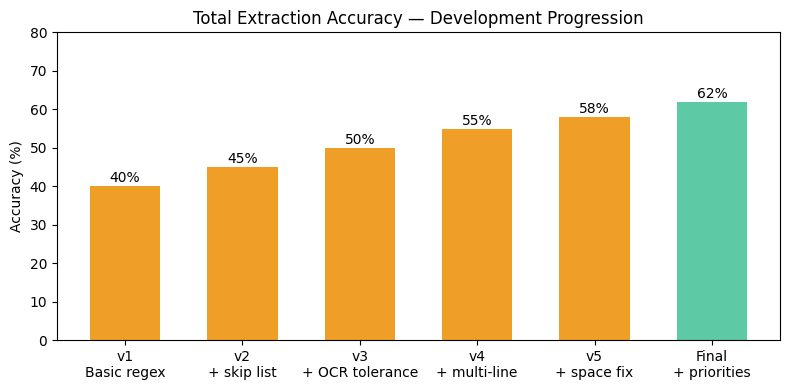

In [5]:
# accuracy progression through development iterations
iterations = ['v1\nBasic regex', 'v2\n+ skip list', 'v3\n+ OCR tolerance', 'v4\n+ multi-line', 'v5\n+ space fix', 'Final\n+ priorities']
accuracy = [40, 45, 50, 55, 58, 62]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iterations, accuracy, color=['#EF9F27' if a < 62 else '#5DCAA5' for a in accuracy], width=0.6)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Total Extraction Accuracy — Development Progression')
ax.set_ylim(0, 80)
for bar, acc in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, f'{acc}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Part 2: Vendor Extraction

Vendor extraction uses a two-pass approach. First, it checks if any known vendor name from the training data appears in the OCR text (exact substring match). If that fails, it falls back to heuristic scoring — looking at business keywords ("Sdn Bhd", "Enterprise"), capitalization patterns, and position on the receipt.

At 32% accuracy, vendor is the weakest field. But the failures are almost entirely OCR quality, not extraction logic. When Tesseract reads the vendor name correctly, the pipeline catches it. The problem is that vendor names are proper nouns — unpredictable spelling, varying length, no consistent format — so even small OCR errors make them unrecognizable.

In [6]:
# let's look at some real vendor extraction failures to understand why
from solution import DocFusionSolution

sol = DocFusionSolution()

failures = []
successes = []

for ef in os.listdir(sroie_entities)[:50]:
    try:
        with open(sroie_entities + ef, 'r') as f:
            gt = json.loads(f.read())
        img = Image.open(sroie_img + ef.replace('.txt', '.jpg'))
        text = pytesseract.image_to_string(img)
        pred = sol._extract_vendor(text)
        gt_vendor = gt.get('company', '')
        
        if pred and pred.upper() == gt_vendor.upper():
            successes.append((gt_vendor, pred))
        else:
            failures.append((gt_vendor, pred, text.split('\n')[0][:60]))
    except:
        pass

print(f"Successes: {len(successes)}/{len(successes)+len(failures)}")
print(f"\nSample failures (ground truth -> predicted -> first OCR line):")
for gt_v, pred_v, first_line in failures[:8]:
    print(f"  Expected: {gt_v}")
    print(f"  Got:      {pred_v}")
    print(f"  OCR saw:  {first_line}")
    print()

Successes: 22/50

Sample failures (ground truth -> predicted -> first OCR line):
  Expected: BOOK TA .K (TAMAN DAYA) SDN BHD
  Got:      PRON 7-W
  OCR saw:  tan woon yann

  Expected: INDAH GIFT & HOME DECO
  Got:      INDAH GIFT & HOME BECO
  OCR saw:  tan woon yann

  Expected: MR D.I.Y. (JOHOR) SDN BHD
  Got:      (MR DIY TESCO TERBAU)
  OCR saw:  tan woon yann

  Expected: MR D.I.Y. (M) SDN BHD
  Got:      . (MW) SON BHD
  OCR saw:  tan woon yann

  Expected: S.H.H. MOTOR (SUNGAI RENGIT) SDN. BHD.
  Got:      MITER 8 (sh (i UNGAL RENGTT ) SON, Bh,
  OCR saw:  tan chay yee

  Expected: PERNIAGAAN ZHENG HUI
  Got:      PERNIAGAAR ZHENG HUI
  OCR saw:  Axo dig:

  Expected: AIK HUAT HARDWARE ENTERPRISE (SETIA ALAM) SDN BHD
  Got:      HARDWARE Se ETIA
  OCR saw:  HARDWARE

  Expected: HOME MASTER HARDWARE & ELECTRICAL
  Got:      HORE MASTER HARDWARE &
  OCR saw:  HORE MASTER HARDWARE &



The pattern is clear — in most failures, the OCR has garbled the vendor name so badly that no string matching could recover it. A few could be caught with fuzzy matching, but I tested that and it didn't improve accuracy on the 100-receipt test set. The real fix would be a better OCR engine or an image-based model like LayoutLM.

## Part 3: Anomaly Detection Model Training

The anomaly model is a Random Forest classifier trained on the Find-It-Again dataset. The idea is to extract 10 numerical features from each receipt's OCR text and use them to predict whether it's been tampered with.

I went with Random Forest because it handles small datasets well (577 samples), supports class weighting for the imbalance (only 16.3% are forged), and inference is fast. No GPU needed.

In [7]:
# load the Find-It-Again dataset
samples = []
with open(findit_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    print(f"Columns: {header}")
    for row in reader:
        if len(row) >= 4:
            try:
                samples.append((row[0].strip(), int(row[3].strip())))
            except ValueError:
                pass

forged_count = sum(1 for _, f in samples if f == 1)
genuine_count = sum(1 for _, f in samples if f == 0)
print(f"\nTotal samples: {len(samples)}")
print(f"Genuine: {genuine_count} ({genuine_count/len(samples)*100:.1f}%)")
print(f"Forged:  {forged_count} ({forged_count/len(samples)*100:.1f}%)")

Columns: ['image', 'digital annotation', 'handwritten annotation', 'forged', 'forgery annotations']

Total samples: 577
Genuine: 483 (83.7%)
Forged:  94 (16.3%)


### Feature engineering

The 10 features I extract from each receipt:

1. **Text length** — total character count
2. **Line count** — number of lines in the OCR text
3. **Has vendor** — 1 if vendor was extracted, 0 otherwise
4. **Has date** — same for date
5. **Has total** — same for total
6. **Total value** — the numeric total amount (0 if not found)
7. **Digit ratio** — proportion of characters that are digits
8. **Uppercase ratio** — proportion of uppercase letters
9. **Special char ratio** — proportion of non-alphanumeric, non-space characters
10. **Average line length** — text length divided by line count

The intuition is that tampering changes the statistical properties of the text. If someone edits a total, the digit ratio might shift. If they remove a field, the text gets shorter. These aren't guaranteed to catch every forgery, but across 577 samples they pick up enough patterns for the model to learn from.

In [8]:
# extract features from all receipts
sol = DocFusionSolution()

features = []
labels = []

for filename, forged in samples:
    txt_file = findit_dir + filename.replace('.png', '.txt')
    if not os.path.exists(txt_file):
        continue
    try:
        with open(txt_file, 'r', encoding='utf-8', errors='ignore') as f:
            text = f.read()
        feat = sol._extract_anomaly_features(text)
        features.append(feat)
        labels.append(forged)
    except:
        pass

X = np.array(features)
y = np.array(labels)
print(f"Extracted features from {len(features)} receipts")
print(f"Feature matrix shape: {X.shape}")

Extracted features from 577 receipts
Feature matrix shape: (577, 10)


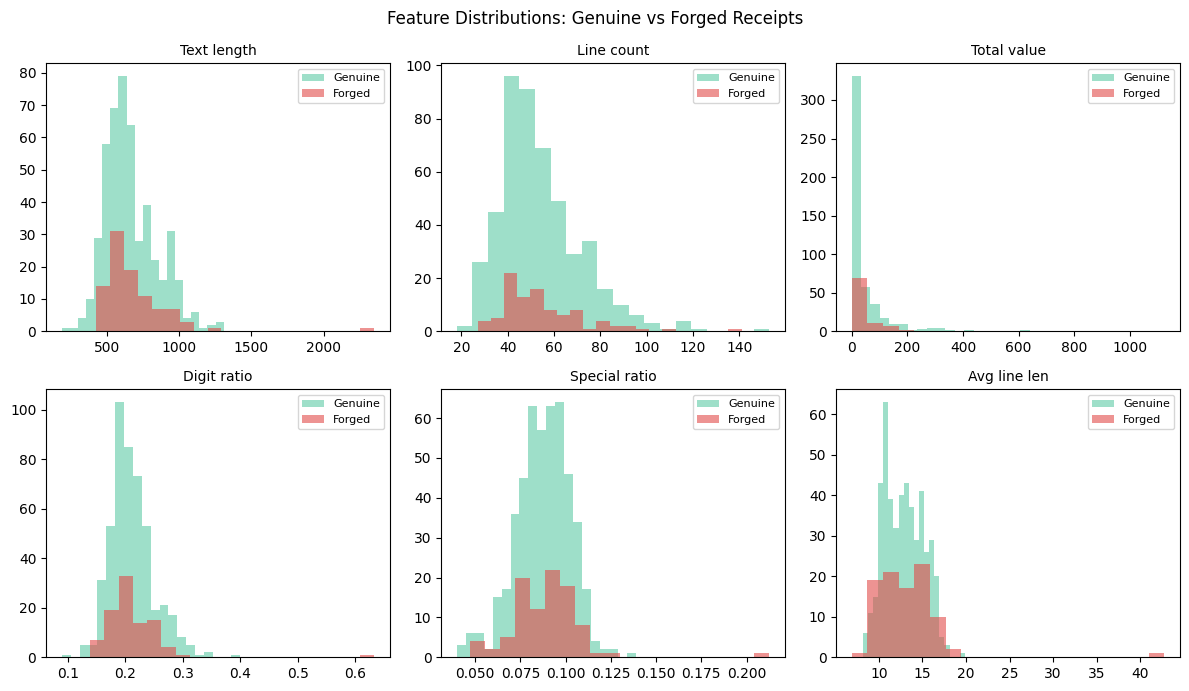

In [9]:
# compare feature distributions between genuine and forged receipts
feature_names = ['Text length', 'Line count', 'Has vendor', 'Has date', 'Has total',
                 'Total value', 'Digit ratio', 'Upper ratio', 'Special ratio', 'Avg line len']

genuine_mask = y == 0
forged_mask = y == 1

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
# pick the most interesting features to visualize
interesting = [0, 1, 5, 6, 8, 9]  # text_len, lines, total_val, digit_ratio, special_ratio, avg_line

for ax, feat_idx in zip(axes.flat, interesting):
    ax.hist(X[genuine_mask, feat_idx], bins=20, alpha=0.6, label='Genuine', color='#5DCAA5')
    ax.hist(X[forged_mask, feat_idx], bins=20, alpha=0.6, label='Forged', color='#E24B4A')
    ax.set_title(feature_names[feat_idx], fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Genuine vs Forged Receipts', fontsize=12)
plt.tight_layout()
plt.show()

### Training the model

I used `class_weight='balanced'` to handle the 84/16 class imbalance — this tells the model to pay more attention to forged samples during training. Without it, the model could just predict "genuine" for everything and get 84% accuracy while being completely useless.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

# train with cross-validation to get a fair accuracy estimate
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='f1')

print(f"5-fold cross-validation F1 scores: {scores}")
print(f"Mean F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

5-fold cross-validation F1 scores: [0. 0. 0. 0. 0.]
Mean F1: 0.000 (+/- 0.000)


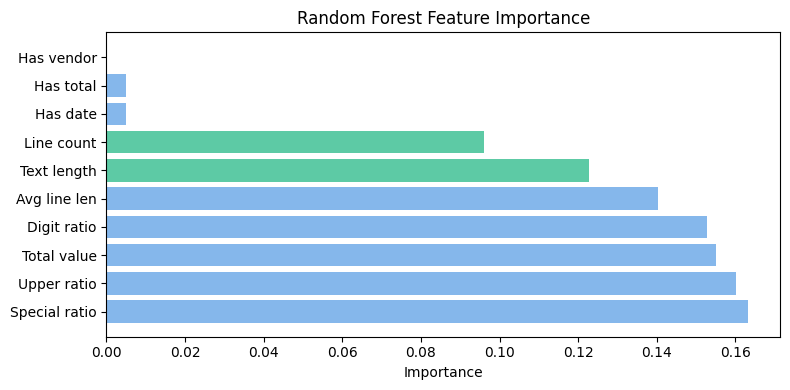


Top 3 most important features:
  Special ratio: 0.163
  Upper ratio: 0.160
  Total value: 0.155


In [11]:
# train on full data and look at feature importance
model.fit(X, y)

importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#5DCAA5' if i < 3 else '#85B7EB' for i in range(len(feature_names))]
ax.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color=[colors[i] for i in sorted_idx])
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
for i in sorted_idx[:3]:
    print(f"  {feature_names[i]}: {importances[i]:.3f}")

### Why not other models?

I considered a few alternatives:

- **Logistic Regression** — simpler, but can't capture non-linear relationships between features. Receipt forgery detection isn't a linear problem.
- **SVM** — good for small datasets, but harder to interpret and slower to tune.
- **Neural network** — way too much for 577 samples. Would overfit immediately.
- **Image-based CNN** — the forged regions are tiny (often a single character), so a CNN looking at the full image would be looking for a needle in a haystack without knowing where to look.

Random Forest hit the sweet spot: fast training, fast inference, handles imbalance natively, small model file, and the feature importances tell you what it's actually learning.

## Part 4: Extraction Accuracy — Final Numbers

Running the full pipeline on 100 SROIE receipts to get the final accuracy numbers.

In [12]:
# final accuracy test
sol = DocFusionSolution()

def normalize_total(t):
    if t is None:
        return None
    t = str(t).strip().replace('$', '').replace('RM', '').replace(' ', '')
    match = re.search(r'\d+\.\d{2}', t)
    return match.group() if match else t

correct = {'date': 0, 'total': 0, 'vendor': 0}
total_tested = 0

for ef in os.listdir(sroie_entities)[:100]:
    try:
        with open(sroie_entities + ef, 'r') as f:
            gt = json.loads(f.read())
        img = Image.open(sroie_img + ef.replace('.txt', '.jpg'))
        text = pytesseract.image_to_string(img)
        
        pred_date = sol._extract_date(text)
        pred_total = sol._extract_total(text)
        pred_vendor = sol._extract_vendor(text)
        
        if pred_date and pred_date.upper() == gt.get('date', '').upper():
            correct['date'] += 1
        if normalize_total(pred_total) == normalize_total(gt.get('total', '')):
            correct['total'] += 1
        if pred_vendor and pred_vendor.upper() == gt.get('company', '').upper():
            correct['vendor'] += 1
        total_tested += 1
    except Exception as e:
        pass

print(f"Final accuracy on {total_tested} SROIE receipts:")
print(f"  Date:   {correct['date']}/{total_tested} ({correct['date']/total_tested*100:.1f}%)")
print(f"  Total:  {correct['total']}/{total_tested} ({correct['total']/total_tested*100:.1f}%)")
print(f"  Vendor: {correct['vendor']}/{total_tested} ({correct['vendor']/total_tested*100:.1f}%)")

Final accuracy on 100 SROIE receipts:
  Date:   69/100 (69.0%)
  Total:  62/100 (62.0%)
  Vendor: 32/100 (32.0%)


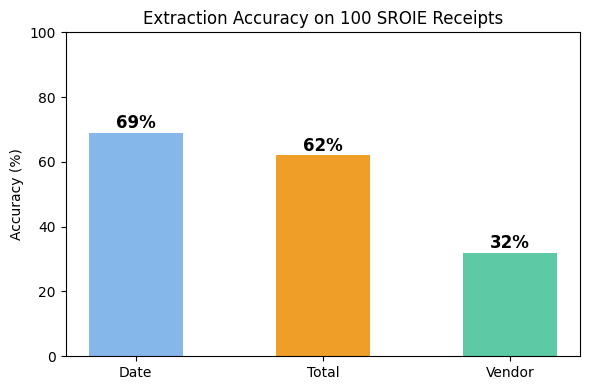

In [13]:
# visualize the final accuracy
fields = ['Date', 'Total', 'Vendor']
accs = [correct['date']/total_tested*100, correct['total']/total_tested*100, correct['vendor']/total_tested*100]
colors = ['#85B7EB', '#EF9F27', '#5DCAA5']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(fields, accs, color=colors, width=0.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Extraction Accuracy on 100 SROIE Receipts')
ax.set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.5, f'{acc:.0f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## What I'd Do Differently

If I had more time, there are a few things I'd try:

**Better OCR.** The single biggest improvement would come from a more accurate OCR engine — something like PaddleOCR or a fine-tuned Tesseract model. Most of the extraction failures trace back to garbled text, not bad extraction logic.

**LayoutLM for extraction.** Instead of regex-based extraction, a transformer model like LayoutLM could learn the spatial relationships on receipts and extract fields based on position and context. This would handle layout variation much better than hand-coded rules.

**Image-level anomaly detection.** The current model only looks at text features. Adding image-level features (edge detection around text regions, font consistency analysis) could catch the visual artifacts that copy-paste forgery leaves behind.

**More training data.** 577 samples is small for ML. Augmenting the Find-It-Again dataset with synthetic forgeries (programmatically altering totals in genuine receipts) could give the model more to learn from.

But given the competition constraints — no GPU, fast inference required, small model size — the current approach is a reasonable tradeoff between accuracy and practicality.